<a href="https://colab.research.google.com/github/danromanoet32/Trabajo-ICCDDgurpo15/blob/main/TP_ICDD_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 1. CARGA DE DATOS
link = 'https://raw.githubusercontent.com/danromanoet32/Trabajo-ICCDDgurpo15/refs/heads/main/customer_behavior_dataset(%20TRABAJO%20CIENCIA%20DATOS).csv'
df = pd.read_csv(link)

# 2. RENOMBRADO DE COLUMNAS
cambio_col = {
    'Year_Birth': 'Edad',
    'Education': 'Educacion',
    'Marital_Status': 'Estado_Civil',
    'Income': 'Ingreso',
    'Kidhome': 'Hijos_Ninos',
    'Teenhome': 'Hijos_Adolescentes',
    'Dt_Customer': 'Fecha_Inscripcion',
    'Recency': 'Dias_Ult_Compra',
    'Z_CostContact': 'Costo_Contacto',
    'Z_Revenue': 'Ganancia',
    'Complain': 'Queja',
    'NumWebPurchases': 'Compras_Web',
    'NumStorePurchases': 'Compras_Fisicas',
    'NumWebVisitsMonth' : 'Visitas_Web',
    'MntGoldProds': 'Prod_prem',
    'NumDealsPurchases': 'Compras_Oferta',
    'NumCatalogPurchases': 'Compras_Catalogo',  #compras con catalogo
    # Campañas
    'Response': 'Ult_Camp',
    'MntWines': 'Gasto_Vinos',
    'MntFruits': 'Gasto_Frutas',
    'MntMeatProducts': 'Gasto_Carne',
    'MntFishProducts': 'Gasto_Pescado',
    'MntSweetProducts': 'Gasto_Dulces',
    'AcceptedCmp1': 'Camp1',
    'AcceptedCmp2': 'Camp2',
    'AcceptedCmp3': 'Camp3',
    'AcceptedCmp4': 'Camp4',
    'AcceptedCmp5': 'Camp5'
}
# Aplicamos el cambio de nombres y guardamos en df_etl
df_etl = df.rename(columns=cambio_col)


df_etl['Edad'] = 2026 - df_etl.iloc[:,1]

# 4. LIMPIEZA DE OUTLIERS Y ANOMALIAS
# Eliminamos clientes con edades absurdas (nacidos antes de 1926)
df_etl = df_etl[df_etl['Edad'] <= 100]
#Cambiamos Dias_ult_compra a numero entero
df_etl['Dias_Ult_Compra']=df_etl['Dias_Ult_Compra'].astype(int)
# Corregimos valores negativos (errores de tipeo) pasándolos a positivo
columnas_dinero = ['Ingreso', 'Gasto_Vinos', 'Gasto_Carne']
for col in columnas_dinero:
    df_etl[col] = df_etl[col].abs()


# 5. TRATAMIENTO DE VALORES
# A. Eventos y Cantidades: si es nulo, asumimos 0
cols_cero = ['Hijos_Ninos', 'Queja', 'Camp3', 'Camp2', 'Ult_Camp',
             'Compras_Oferta', 'Gasto_Dulces', 'Gasto_Carne', 'Gasto_Pescado']
df_etl[cols_cero] = df_etl[cols_cero].fillna(0)
#Redondeo de datos columna
for col in df_etl.columns:
  df_etl[col]=df_etl[col].round()
# Ingresos: si es nulo, rellenamos con la mediana para no arruinar promedios
df_etl['Ingreso'] = df_etl['Ingreso'].fillna(df_etl['Ingreso'].median())

# LIMPIEZA DE CATEGORIAS (Estado Civil)
trad={'Married': 'Casado', 'Together': 'En pareja', 'Single': 'Soltero', 'Divorced': 'Divorciado', 'Widow': 'Viudo'}
df_etl['Estado_Civil'] = df_etl['Estado_Civil'].replace(trad)
diccionario_estado = {'Alone': 'Soltero', 'YOLO': 'Soltero', 'Absurd': 'Soltero'}
df_etl['Estado_Civil'] = df_etl['Estado_Civil'].replace(diccionario_estado)

# 7. ELIMINACION DE COLUMNAS INNECESARIAS
# Costo_Contacto y Ganancia son exactamente iguales para todos los clientes, no sirven.
df_etl = df_etl.drop(columns=['Costo_Contacto', 'Ganancia'])

# 8. REORDENAMIENTO DE COLUMNAS (Campañas)
# Obtenemos la lista de todas las columnas actuales
columnas = list(df_etl.columns)
# Definimos el orden lógico y secuencial que queremos para las campañas
campanias_ordenadas = ['Camp1', 'Camp2', 'Camp3', 'Camp4', 'Camp5', 'Ult_Camp']
# Sacamos estas campañas de su posición original desordenada
for camp in campanias_ordenadas:
    columnas.remove(camp)
# Las volvemos a agregar al final de la tabla, pero ya con el orden correcto
columnas.extend(campanias_ordenadas)
# Aplicamos el nuevo orden al DataFrame
df_etl = df_etl[columnas]

# 9. VERIFICACIÓN FINAL
print("--- RESULTADO DEL PROCESO ETL ---")
print(f"Filas finales (clientes válidos): {df_etl.shape[0]}")
print(f"Columnas finales: {df_etl.shape[1]}")
print(f"Cantidad total de datos nulos restantes: {df_etl.isnull().sum().sum()}")

df_final=df_etl.copy()
#Creacion de columna rango etario
limites = list(range(20, 90, 5))

# Creamos las etiquetas  (ej: "20-24")
# El bucle recorre la lista de límites creando pares: "20-24", "25-29", etc.
etiquetas = [f"{limites[i]}-{limites[i+1]-1}" for i in range(len(limites)-1)]

# Usamos pd.cut() de Pandas para categorizar cada edad en su rango correspondiente
df_final['Rango_Etario'] = pd.cut(df_final['Edad'], bins=limites, labels=etiquetas, right=False)
#Chequeo valores edad para saber el rango etario correspondiente p/grafico posterior
print(df_final['Edad'].min(), df_final['Edad'].max())
print(df_final['Educacion'].unique())


--- RESULTADO DEL PROCESO ETL ---
Filas finales (clientes válidos): 2237
Columnas finales: 27
Cantidad total de datos nulos restantes: 0
30 86
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


In [ ]:
# 1. Guardar el archivo en el entorno de Colab
#df_final.to_csv('df_post_etl.csv', index=False,)

# 2. Descargarlo a tu computadora (lo pongo como nota para no descargalo cada vez que se ejecuta todo)
# from google.colab import files
# files.download('df_post_etl.csv')

In [ ]:
limites = list(range(20, 90, 5))


# El bucle recorre la lista de límites creando pares: "20-24", "25-29", etc.
etiquetas = [f"{limites[i]}-{limites[i+1]-1}" for i in range(len(limites)-1)]

# Usamos pd.cut() de Pandas para categorizar cada edad en su rango correspondiente
df_final['Rango_Etario'] = pd.cut(df_final['Edad'], bins=limites, labels=etiquetas, right=False)
#Chequeo valores edad para saber el rango etario correspondiente p/grafico posterior
print(df_final['Edad'].min(), df_final['Edad'].max())


30 86


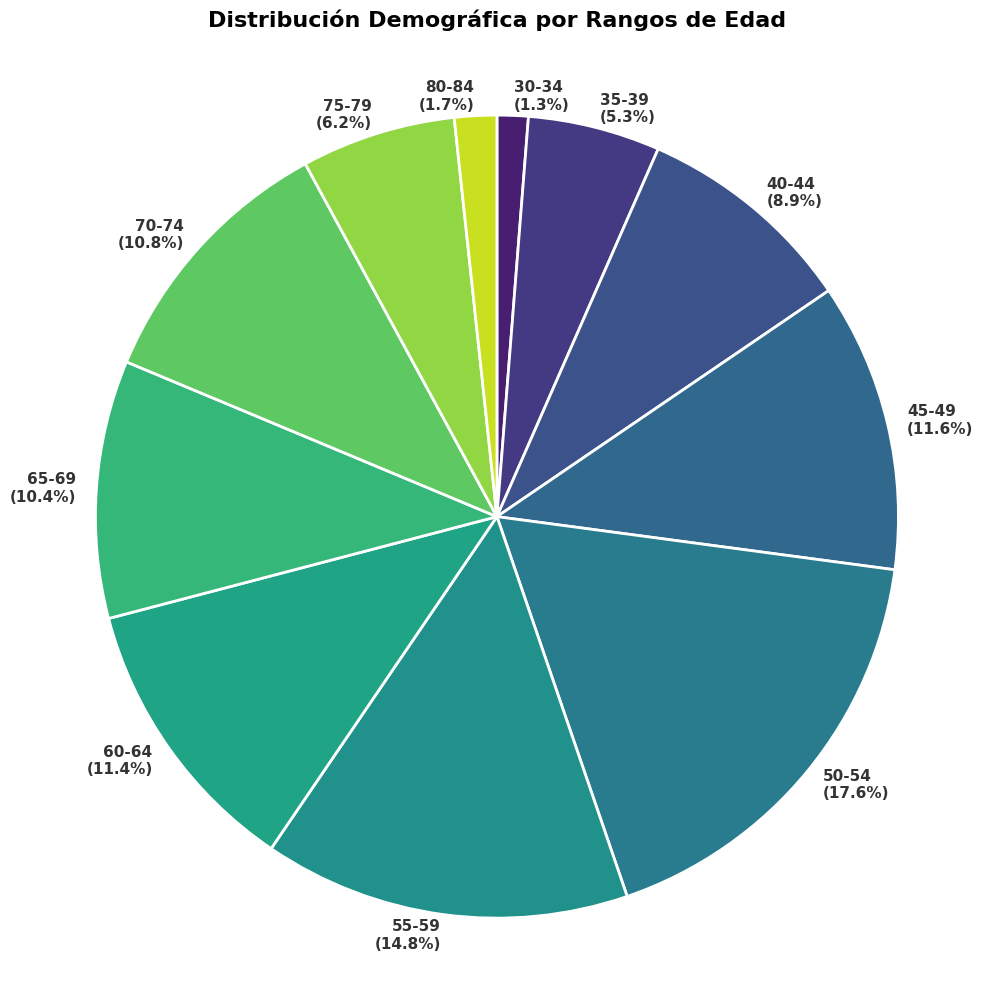

In [ ]:



 #--- 3. CREACIÓN DEL GRÁFICO DE TORTA ---

# Primero contamos cuántos consumidores hay en cada rango
conteo_edades = df_final['Rango_Etario'].value_counts(sort=False)
# Filtramos los rangos que tienen 0 personas para no tener porciones vacías
conteo_edades = conteo_edades[conteo_edades > 0]

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns





# --- 3. PREPARACIÓN DE LOS DATOS ---
conteo_edades = df_final['Rango_Etario'].value_counts(sort=False)
conteo_edades = conteo_edades[conteo_edades > 0]
porcentajes = 100. * conteo_edades / conteo_edades.sum()
etiquetas_combinadas = [f'{rango}\n({pct:.1f}%)' for rango, pct in zip(conteo_edades.index, porcentajes)]

# --- 4. CREACIÓN DEL GRÁFICO ---
plt.figure(figsize=(10, 10))
colores = sns.color_palette('viridis', len(conteo_edades))

plt.pie(
    conteo_edades,
    labels=etiquetas_combinadas,
    autopct=None,
    startangle=90,
    counterclock=False,
    colors=colores,
    labeldistance=1.05,
    textprops={'fontsize': 11, 'weight': 'bold', 'color': '#333333'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# --- 5. DETALLES FINALES ---
plt.title('Distribución Demográfica por Rangos de Edad', fontsize=16, pad=20, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

<Figure size 1600x700 with 0 Axes>

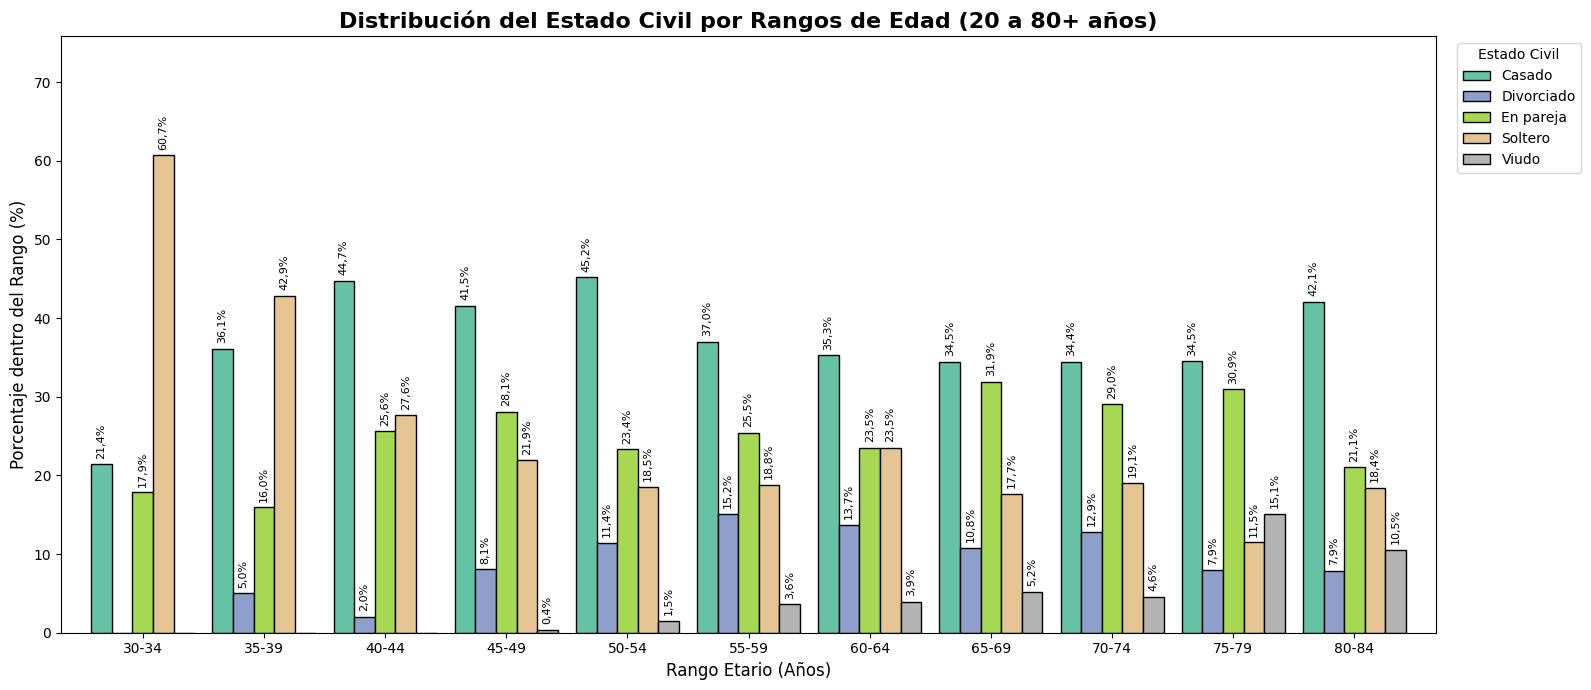

In [ ]:
# CREACIÓN DEL GRÁFICO: Estado Civil por Rango Etario (Intervalos de 5 años)

# Quitamos los espacios en blanco finales de los estados civiles por si acaso
df_final['Estado_Civil'] = df_final['Estado_Civil'].str.strip()

# Definimos los rangos etarios usando el bloque 4
limites = list(range(20, 90, 5))
etiquetas = [f"{limites[i]}-{limites[i+1]-1}" for i in range(len(limites)-1)]

# Aplicamos los cortes a la columna Edad con right=False (incluye límite inferior, excluye superior)
df_final['Rango_Etario'] = pd.cut(df_final['Edad'], bins=limites, labels=etiquetas, right=False)

# Calculamos los porcentajes relativos dentro de cada rango etario
# normalize='index' asegura que la suma de opciones dentro de "20-24", por ej., dé 100%
datos_grafico_pct = pd.crosstab(df_final['Rango_Etario'], df_final['Estado_Civil'], normalize='index') * 100


# Generamos el gráfico de barras agrupadas
plt.figure(figsize=(16, 7))

ax = datos_grafico_pct.plot(kind='bar', figsize=(16, 7), colormap='Set2', width=0.85, edgecolor='black')

# Configuramos títulos y etiquetas
plt.title('Distribución del Estado Civil por Rangos de Edad (20 a 80+ años)', fontsize=16, fontweight='bold')
plt.xlabel('Rango Etario (Años)', fontsize=12)
plt.ylabel('Porcentaje dentro del Rango (%)', fontsize=12)

# Dejamos las etiquetas del eje X horizontales
plt.xticks(rotation=0)

# Movemos la leyenda afuera del gráfico
plt.legend(title='Estado Civil', bbox_to_anchor=(1.01, 1), loc='upper left')

#Agregamos las etiquetas de porcentaje sobre cada barra
for p in ax.patches:
    alto = p.get_height()
    # Solo mostramos el texto si el porcentaje es mayor a cero
    if alto > 0:
        # Formateamos a 1 decimal y aplicamos la coma decimal
        texto = f'{alto:.1f}%'.replace('.', ',')

        ax.annotate(texto,
                    (p.get_x() + p.get_width() / 2., alto),
                    ha='center', va='bottom',
                    xytext=(0, 4), # Desplaza el texto 4 puntos hacia arriba
                    textcoords='offset points',
                    fontsize=8, # Letra más pequeña
                    rotation=90) # Rotamos el número para que quepa en barras finas

plt.ylim(0, datos_grafico_pct.max().max() * 1.25)

plt.tight_layout()
plt.show()

/tmp/ipykernel_14930/3243664964.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


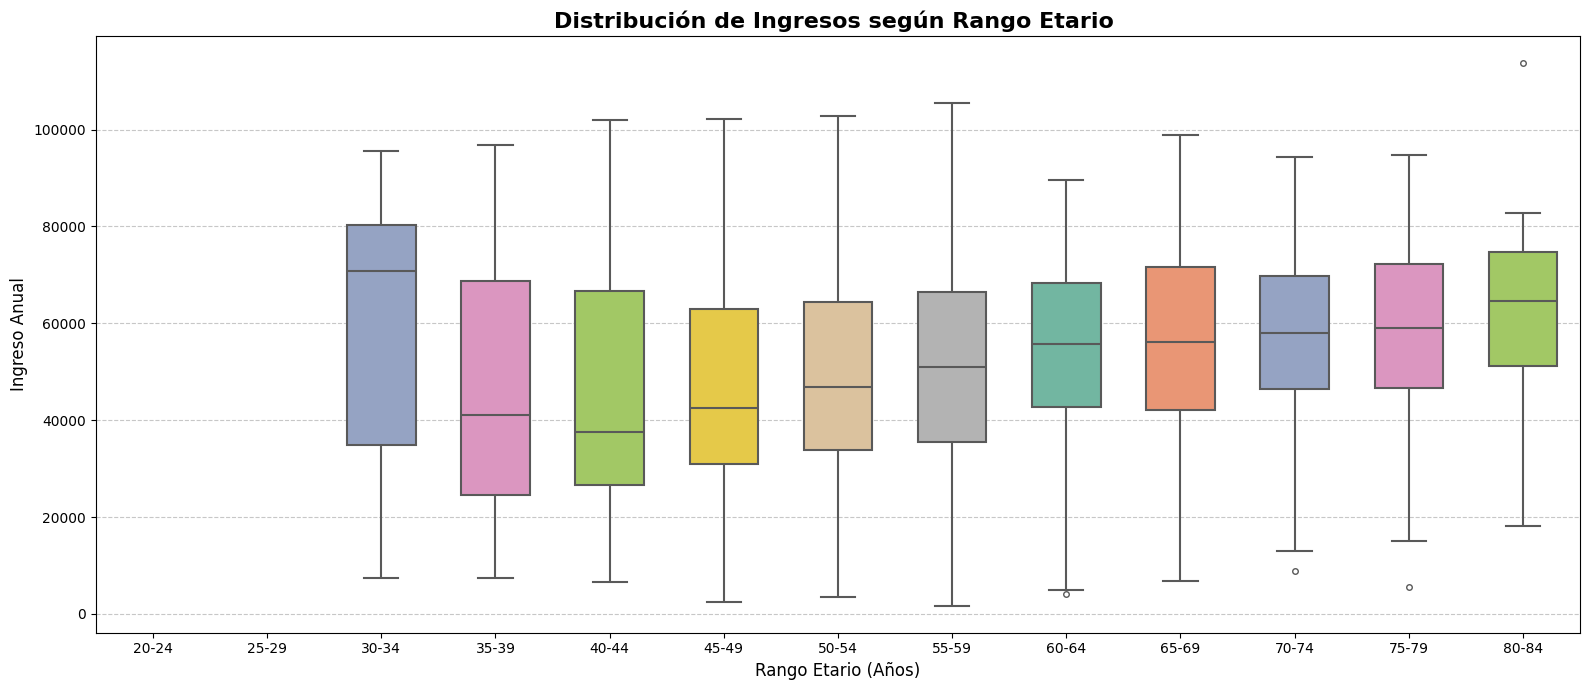

In [ ]:
#  CREACIÓN DEL GRÁFICO: Ingresos por Rango Etario (Boxplot)

#  Definimos los rangos etarios (misma estructura de 5 años)
limites = list(range(20, 90, 5))
etiquetas = [f"{limites[i]}-{limites[i+1]-1}" for i in range(len(limites)-1)]

# Aplicamos los cortes a la columna Edad
df_final['Rango_Etario'] = pd.cut(df_final['Edad'], bins=limites, labels=etiquetas, right=False)

# Filtramos los ingresos mayores a 150.000 para eliminar el outlier contextual (666.666)
# que estaba "aplastando" la escala del gráfico.
df_grafico = df_final[df_final['Ingreso'] < 150000]

# Generamos el gráfico de caja (Boxplot)
plt.figure(figsize=(16, 7))

# ATENCIÓN: Usamos df_grafico (el que no tiene el outlier) en lugar de df_final
ax = sns.boxplot(
    data=df_grafico,
    x='Rango_Etario',
    y='Ingreso',
    palette='Set2',
    width=0.6,
    linewidth=1.5,
    fliersize=4
)

# Configuramos títulos y etiquetas
plt.title('Distribución de Ingresos según Rango Etario ', fontsize=16, fontweight='bold')
plt.xlabel('Rango Etario (Años)', fontsize=12)
plt.ylabel('Ingreso Anual', fontsize=12)

# Dejamos las etiquetas del eje X horizontales
plt.xticks(rotation=0)

# Agregamos una cuadrícula horizontal suave para leer mejor la escala
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

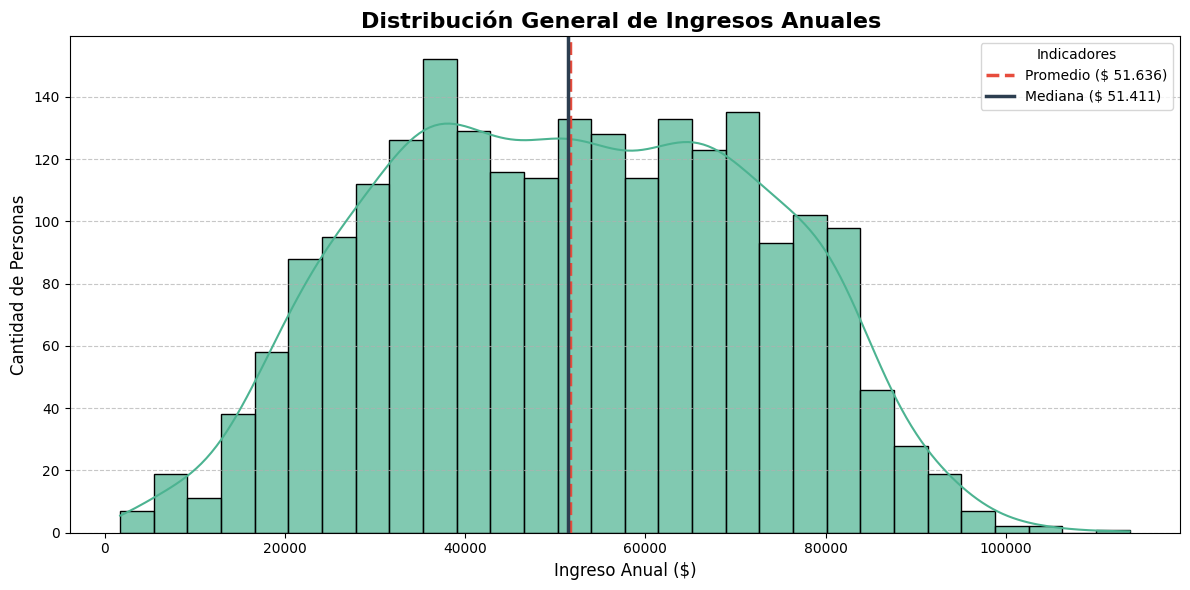

In [ ]:
# CREACIÓN DEL GRÁFICO: Distribución General de Ingresos (Histograma + KDE)

#  Filtramos los ingresos mayores a 150.000 para eliminar el outlier extremo
# Esto nos permite ver la distribución real de nuestro público objetivo
df_grafico = df_final[df_final['Ingreso'] < 150000]

# Calculamos el promedio y la mediana para agregarlos al gráfico
promedio = df_grafico['Ingreso'].mean()
mediana = df_grafico['Ingreso'].median()

# Formateamos los números al estilo local (punto para los separadores de miles)
promedio_str = f"$ {int(promedio):,}".replace(',', '.')
mediana_str = f"$ {int(mediana):,}".replace(',', '.')

# Generamos el gráfico
plt.figure(figsize=(12, 6))

# Dibujamos el histograma con la curva de densidad (KDE) usando Seaborn
sns.histplot(
    data=df_grafico,
    x='Ingreso',
    bins=30,             # 30 intervalos es el equilibrio ideal para este volumen de datos
    kde=True,            # Activa la curva de tendencia
    color='#4CB391',
    edgecolor='black',
    alpha=0.7            # Ligera transparencia para no tapar el fondo
)

# Agregamos las líneas de Promedio y Mediana
# Promedio en línea punteada roja, Mediana en línea sólida oscura
plt.axvline(promedio, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Promedio ({promedio_str})')
plt.axvline(mediana, color='#2c3e50', linestyle='-', linewidth=2.5, label=f'Mediana ({mediana_str})')

#  Configuramos títulos y etiquetas
plt.title('Distribución General de Ingresos Anuales ', fontsize=16, fontweight='bold')
plt.xlabel('Ingreso Anual ($)', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)

# Colocamos la leyenda en la esquina superior derecha
plt.legend(loc='upper right', title='Indicadores', fontsize=10)

# Agregamos una cuadrícula de fondo horizontal para facilitar la lectura de cantidades
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
columnas_marketing = ['Camp1','Camp2', 'Camp3', 'Camp4', 'Camp5', 'Ult_Camp']


tabla_resumen = df_final[columnas_marketing].apply(pd.Series.value_counts).T

print(tabla_resumen)

             0    1
Camp1     2093  144
Camp2     2215   22
Camp3     2101  136
Camp4     2070  167
Camp5     2075  162
Ult_Camp  1909  328


--- Resumen Numérico ---
              Compras_Catalogo  Compras_Web  Compras_Fisicas
Rango_Etario                                                
20-24                        0          0.0                0
25-29                        0          0.0                0
30-34                      117         96.0              165
35-39                      325        458.0              692
40-44                      413        740.0              965
45-49                      572        984.0             1390
50-54                      872       1590.0             2118
55-59                      818       1484.0             1892
60-64                      718       1128.0             1547
65-69                      713       1050.0             1427
70-74                      787       1192.0             1566
75-79                      459        620.0              898
80-84                      151        233.0              293
------------------------


/tmp/ipykernel_14930/523589245.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_compras = df_final.groupby('Rango_Etario')[columnas_a_comparar].sum()


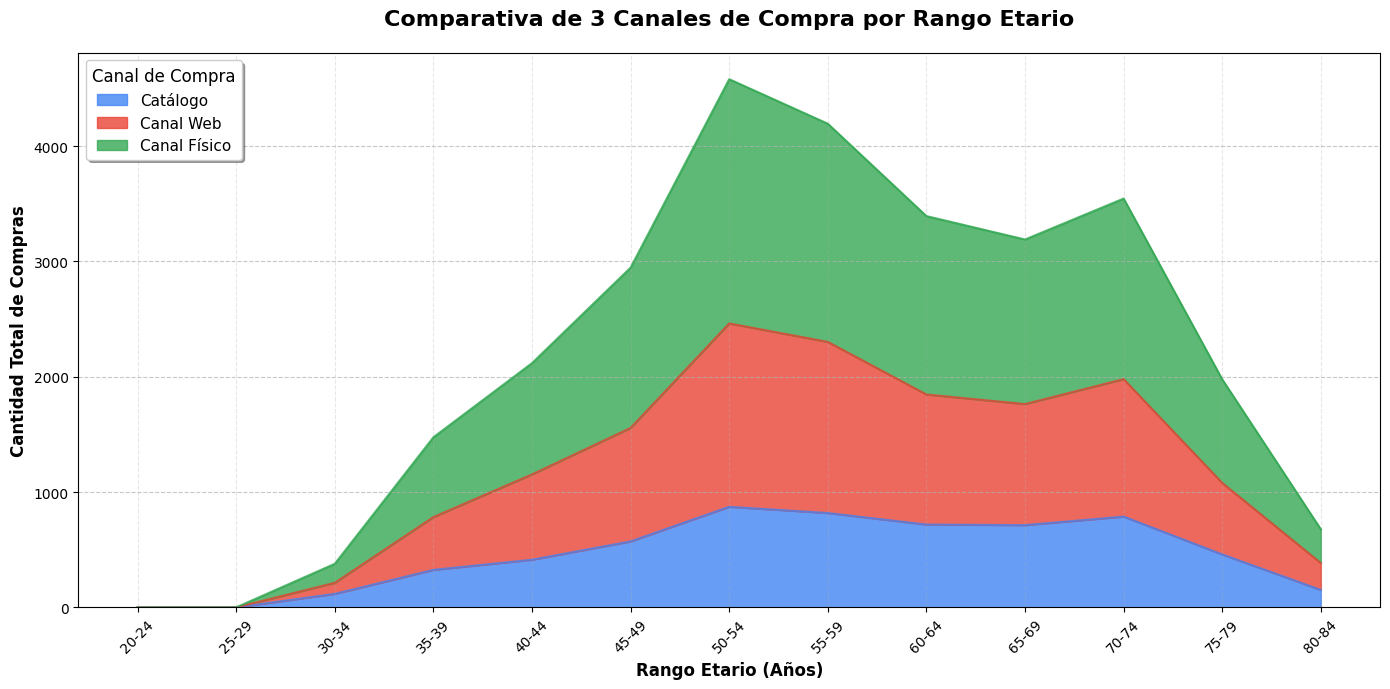

In [ ]:
columnas_a_comparar = ['Compras_Catalogo','Compras_Web', 'Compras_Fisicas',]

# Agrupamos por edad y sumamos el total de compras de cada canal
resumen_compras = df_final.groupby('Rango_Etario')[columnas_a_comparar].sum()


print("--- Resumen Numérico ---")
print(resumen_compras)
print("-" * 24)

# --- 2. CREACIÓN DEL GRÁFICO ---
plt.figure(figsize=(14, 7))

ax = resumen_compras.plot(
    kind='area',
    stacked=True,
    figsize=(14, 7),
    color=['#4285F4', '#EA4335', '#34A853'],
    alpha=0.8,
    ax=plt.gca()
)

# --- 3. DETALLES ESTÉTICOS ---
plt.title('Comparativa de 3 Canales de Compra por Rango Etario',
          fontsize=16, weight='bold', pad=20)
plt.xlabel('Rango Etario (Años)', fontsize=12, weight='bold')
plt.ylabel('Cantidad Total de Compras', fontsize=12, weight='bold')

handles, labels = ax.get_legend_handles_labels()

# Arreglamos la leyenda usando los handles correctos y actualizamos "Catálogo"
plt.legend(handles, ['Catálogo','Canal Web','Canal Físico'], title='Canal de Compra',
           title_fontsize='12', fontsize='11', loc='upper left', shadow=True)

# Aseguramos que se lean todas las etiquetas del eje X
plt.xticks(range(len(resumen_compras.index)), resumen_compras.index, rotation=45)

# Cuadrícula horizontal y vertical para facilitar la lectura del área
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:



#Ordinal Encoding para Educación (Mantiene jerarquía y concentra importancia)
diccionario_educacion = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
df_final['Educacion'] = df_final['Educacion'].map(diccionario_educacion)

# B. One-Hot Encoding para Estado Civil (Evita crear falsas jerarquías matemáticas)
# Usamos pd.get_dummies() para aplicar variables dummy (One-Hot Encoding).
# Esto convertirá las categorías de texto en nuevas columnas de True/False (o 1s y 0s).
# Lo aplicamos a 'Estado_Civil'.
df_final = pd.get_dummies(df_final, columns=['Estado_Civil'], dtype=int)

# -------------------------------------------------------------------
# 2. INGENIERÍA DE ATRIBUTOS: Fechas (Clase 8)
# -------------------------------------------------------------------
# Primero le decimos a pandas que lea la columna como un formato de Fecha y Hora.
df_final['Fecha_Inscripcion'] = pd.to_datetime(df_final['Fecha_Inscripcion'], format='%d-%m-%Y')

# Como en su Fase 1 calcularon la Edad restando el año de nacimiento a 2026,
# usaremos el 1 de enero de 2026 como fecha de referencia para la antigüedad.
fecha_referencia = pd.to_datetime('2026-01-01')

# Restamos las fechas y extraemos solo los días (.dt.days) para tener un número entero.
df_final['Antiguedad_Dias'] = (fecha_referencia - df_final['Fecha_Inscripcion']).dt.days

# Eliminamos la fecha original en formato calendario porque ya no nos sirve para el modelo.
df_final = df_final.drop(columns=['Fecha_Inscripcion'])



# Creamos la nueva variable sintética sumando todos los montos de compras.
df_final['Gasto_Total'] = (df_final['Gasto_Vinos'] +
                           df_final['Gasto_Frutas'] +
                           df_final['Gasto_Carne'] +
                           df_final['Gasto_Pescado'] +
                           df_final['Gasto_Dulces'] +
                           df_final['Prod_prem'])



 Prediccion: Camp1
 Usando historial de: Ninguna (Solo datos demográficos y base)
 Exactitud del Árbol de Decisión: 0,9256
 Exactitud del Bosque Aleatorio: 0,9390

   Top 3 variables más importantes (Random Forest):
   - Ingreso: 0,1268
   - Gasto_Vinos: 0,1073
   - Gasto_Total: 0,0976

   Lista completa de importancia de variables:
   - Ingreso: 0,1268
   - Gasto_Vinos: 0,1073
   - Gasto_Total: 0,0976
   - Gasto_Carne: 0,0699
   - Antiguedad_Dias: 0,0611
   - Gasto_Frutas: 0,0610
   - Gasto_Pescado: 0,0579
   - Gasto_Dulces: 0,0534
   - Compras_Catalogo: 0,0491
   - Edad: 0,0474
   - Dias_Ult_Compra: 0,0459
   - Prod_prem: 0,0431
   - Compras_Web: 0,0335
   - Visitas_Web: 0,0311
   - Compras_Fisicas: 0,0279
   - Educacion: 0,0219
   - Compras_Oferta: 0,0175
   - Hijos_Adolescentes: 0,0128
   - Estado_Civil_Casado: 0,0091
   - Estado_Civil_Soltero: 0,0071
   - Estado_Civil_Viudo: 0,0057
   - Estado_Civil_En pareja: 0,0053
   - Hijos_Ninos: 0,0042
   - Estado_Civil_Divorciado: 0,0036
 

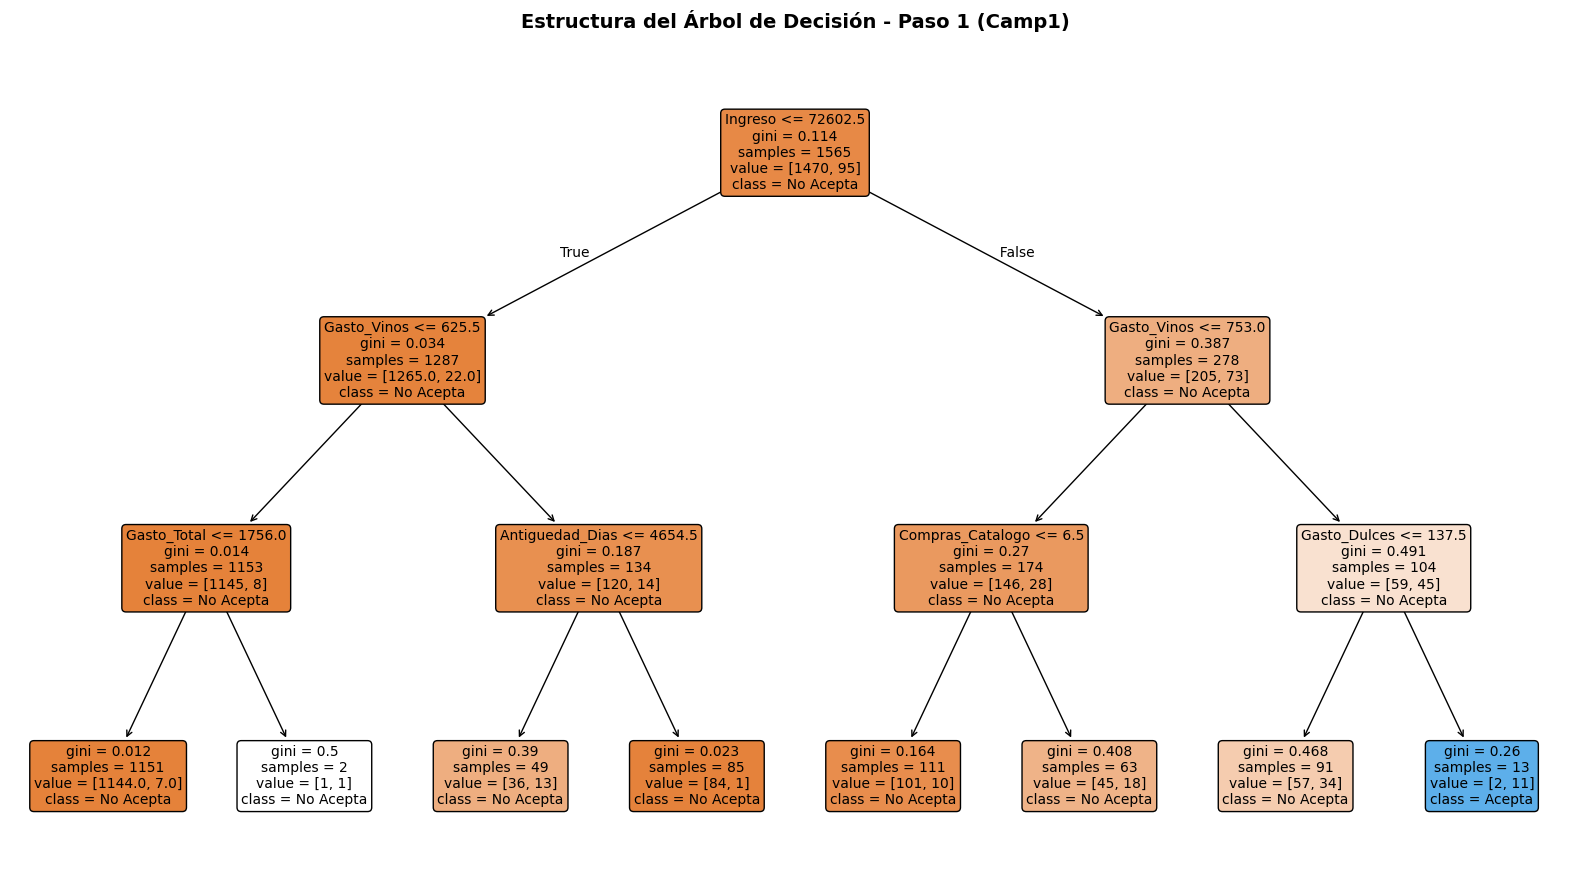


 Prediccion: Camp2
 Usando historial de: Camp1
 Exactitud del Árbol de Decisión: 0,9866
 Exactitud del Bosque Aleatorio: 0,9940

   Top 3 variables más importantes (Random Forest):
   - Gasto_Vinos: 0,1347
   - Gasto_Total: 0,1071
   - Ingreso: 0,0880

   Lista completa de importancia de variables:
   - Gasto_Vinos: 0,1347
   - Gasto_Total: 0,1071
   - Ingreso: 0,0880
   - Gasto_Carne: 0,0821
   - Antiguedad_Dias: 0,0662
   - Prod_prem: 0,0541
   - Dias_Ult_Compra: 0,0452
   - Compras_Web: 0,0430
   - Compras_Oferta: 0,0424
   - Gasto_Pescado: 0,0415
   - Compras_Fisicas: 0,0406
   - Edad: 0,0364
   - Gasto_Frutas: 0,0343
   - Gasto_Dulces: 0,0341
   - Visitas_Web: 0,0284
   - Compras_Catalogo: 0,0242
   - Camp1: 0,0201
   - Educacion: 0,0169
   - Estado_Civil_Divorciado: 0,0125
   - Estado_Civil_En pareja: 0,0118
   - Hijos_Ninos: 0,0106
   - Estado_Civil_Soltero: 0,0075
   - Estado_Civil_Casado: 0,0069
   - Estado_Civil_Viudo: 0,0062
   - Hijos_Adolescentes: 0,0054
   - Queja: 0,000

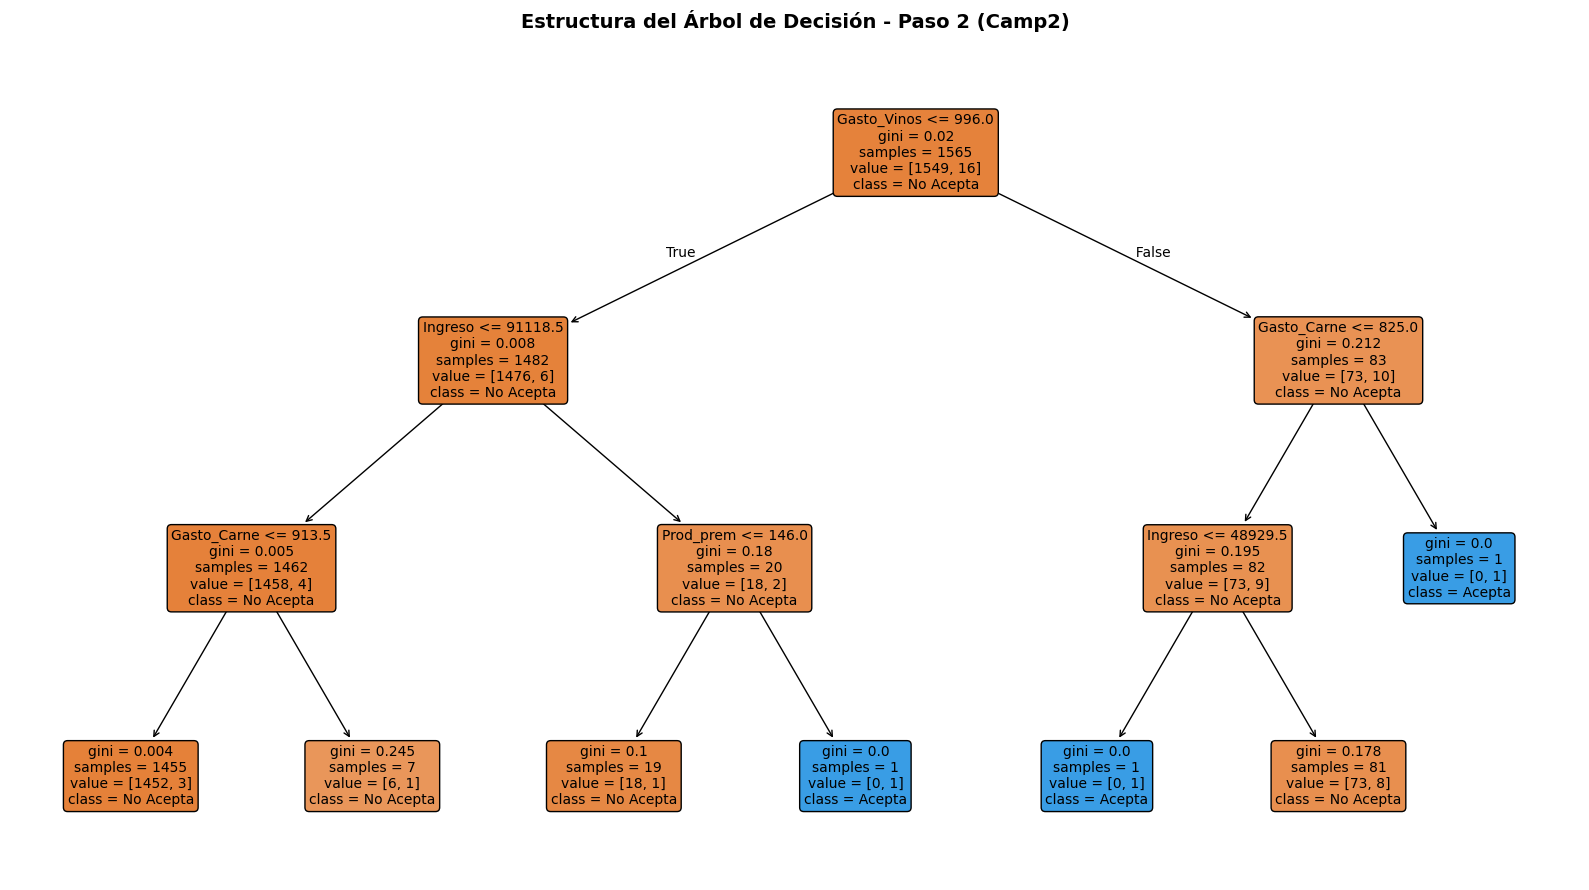


 Prediccion: Camp3
 Usando historial de: Camp1, Camp2
 Exactitud del Árbol de Decisión: 0,9479
 Exactitud del Bosque Aleatorio: 0,9539

   Top 3 variables más importantes (Random Forest):
   - Prod_prem: 0,0885
   - Gasto_Total: 0,0857
   - Ingreso: 0,0694

   Lista completa de importancia de variables:
   - Prod_prem: 0,0885
   - Gasto_Total: 0,0857
   - Ingreso: 0,0694
   - Compras_Fisicas: 0,0677
   - Antiguedad_Dias: 0,0632
   - Gasto_Vinos: 0,0630
   - Gasto_Carne: 0,0619
   - Dias_Ult_Compra: 0,0574
   - Compras_Catalogo: 0,0542
   - Edad: 0,0506
   - Visitas_Web: 0,0447
   - Gasto_Frutas: 0,0437
   - Gasto_Pescado: 0,0399
   - Gasto_Dulces: 0,0392
   - Compras_Web: 0,0356
   - Educacion: 0,0284
   - Compras_Oferta: 0,0276
   - Camp2: 0,0123
   - Hijos_Adolescentes: 0,0112
   - Hijos_Ninos: 0,0102
   - Camp1: 0,0100
   - Estado_Civil_Soltero: 0,0096
   - Estado_Civil_Casado: 0,0085
   - Estado_Civil_En pareja: 0,0084
   - Estado_Civil_Divorciado: 0,0059
   - Estado_Civil_Viudo: 

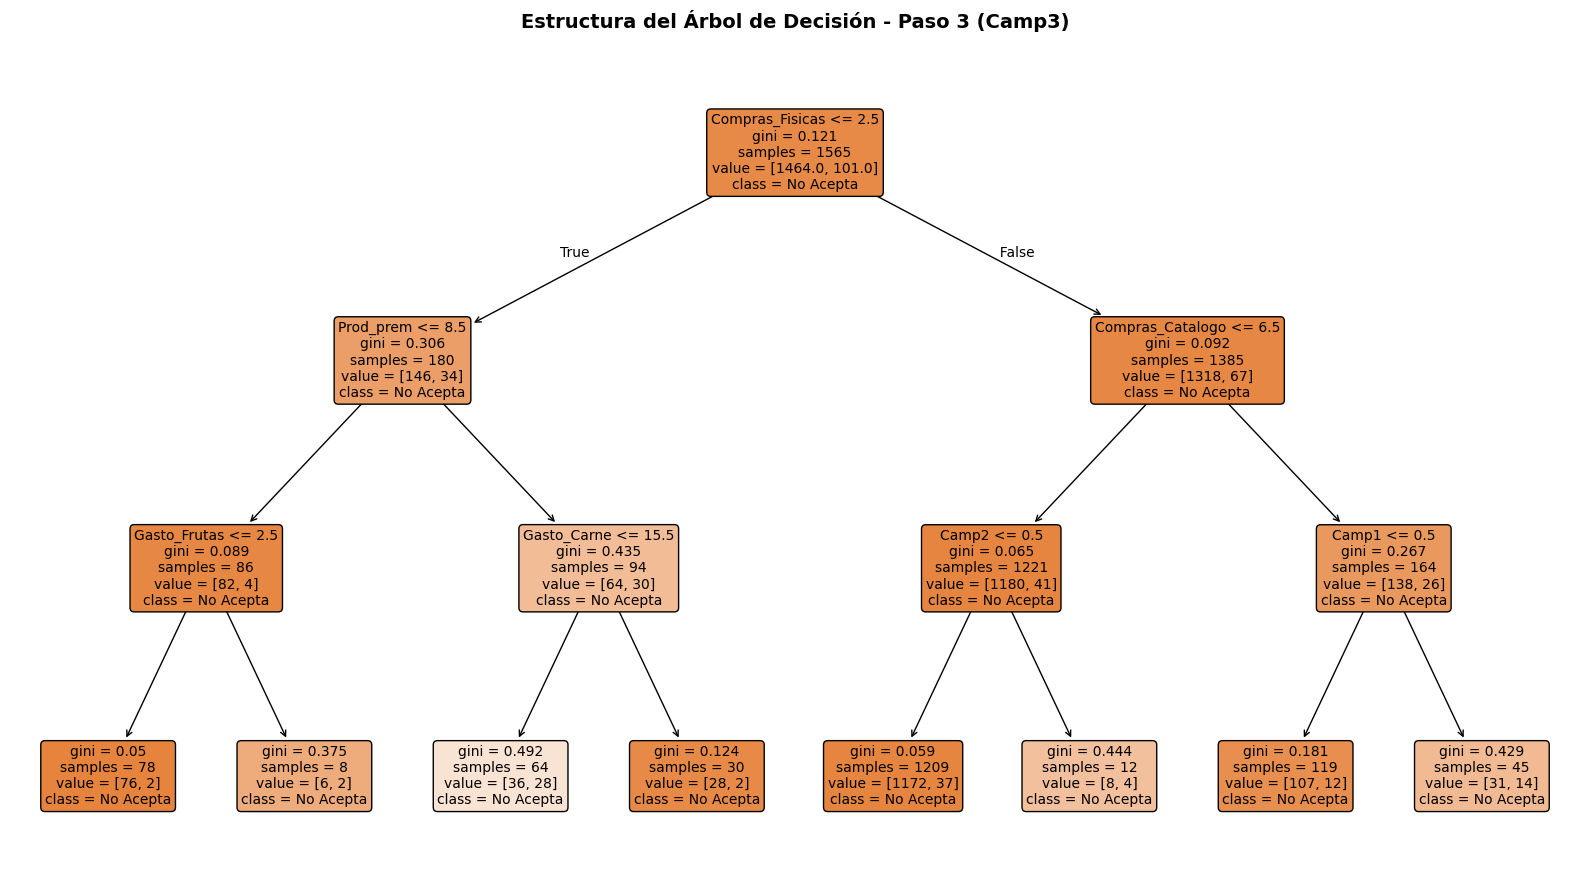


 Prediccion: Camp4
 Usando historial de: Camp1, Camp2, Camp3
 Exactitud del Árbol de Decisión: 0,9033
 Exactitud del Bosque Aleatorio: 0,9152

   Top 3 variables más importantes (Random Forest):
   - Gasto_Vinos: 0,1317
   - Gasto_Total: 0,0745
   - Ingreso: 0,0667

   Lista completa de importancia de variables:
   - Gasto_Vinos: 0,1317
   - Gasto_Total: 0,0745
   - Ingreso: 0,0667
   - Gasto_Carne: 0,0653
   - Dias_Ult_Compra: 0,0642
   - Antiguedad_Dias: 0,0605
   - Prod_prem: 0,0561
   - Gasto_Pescado: 0,0482
   - Edad: 0,0465
   - Gasto_Dulces: 0,0448
   - Gasto_Frutas: 0,0432
   - Visitas_Web: 0,0385
   - Compras_Web: 0,0363
   - Camp1: 0,0361
   - Compras_Fisicas: 0,0361
   - Camp2: 0,0311
   - Compras_Catalogo: 0,0272
   - Compras_Oferta: 0,0267
   - Educacion: 0,0187
   - Hijos_Adolescentes: 0,0086
   - Estado_Civil_Casado: 0,0085
   - Camp3: 0,0073
   - Estado_Civil_En pareja: 0,0066
   - Estado_Civil_Soltero: 0,0059
   - Hijos_Ninos: 0,0049
   - Estado_Civil_Divorciado: 0,00

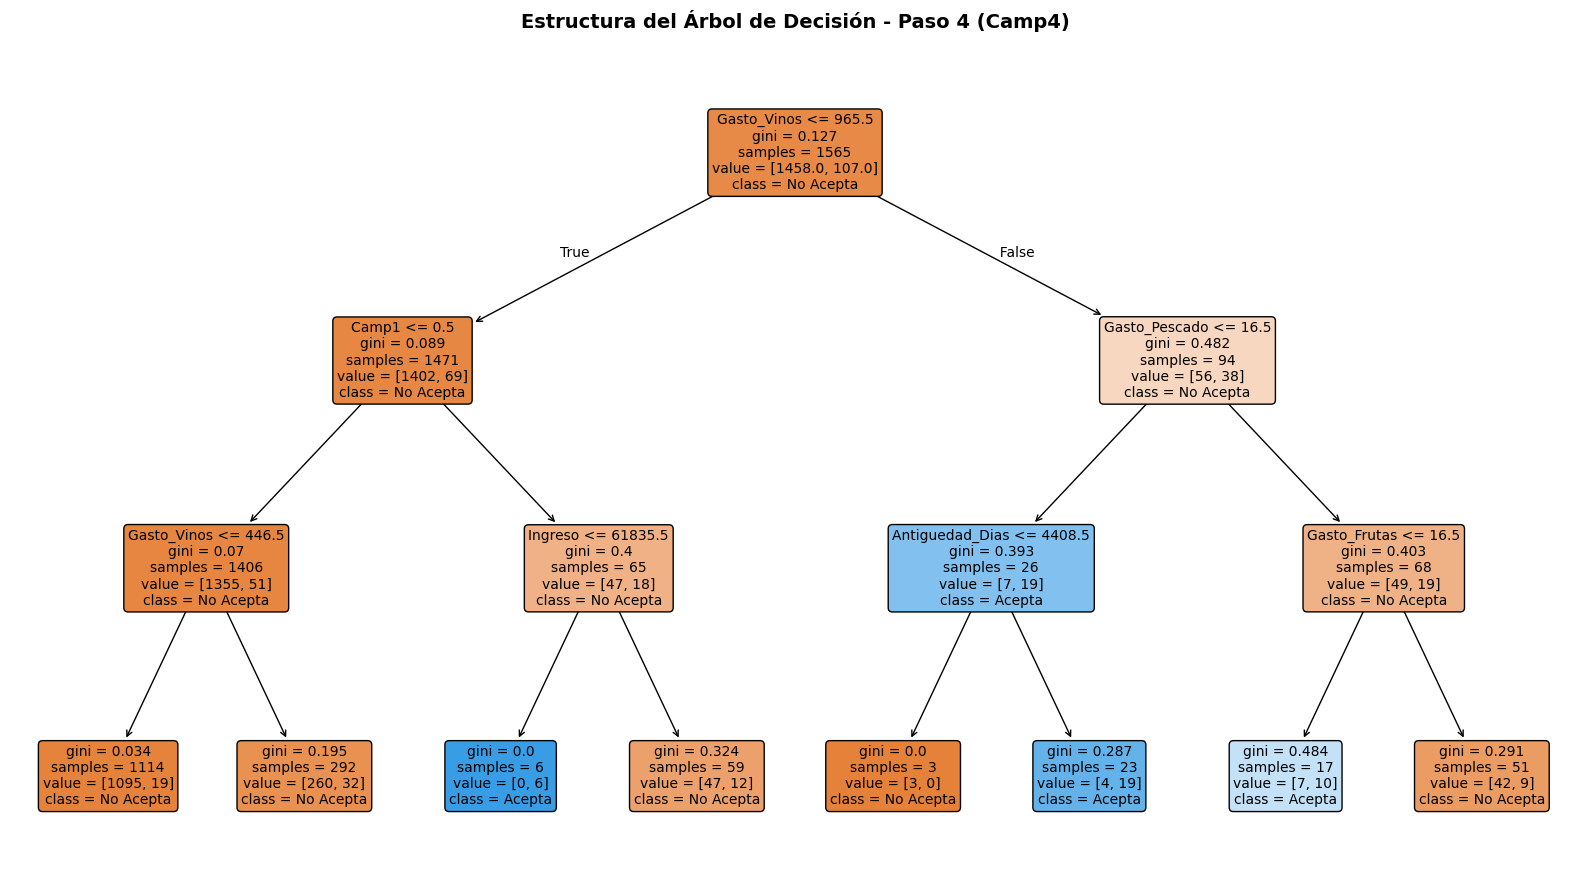


 Prediccion: Camp5
 Usando historial de: Camp1, Camp2, Camp3, Camp4
 Exactitud del Árbol de Decisión: 0,9435
 Exactitud del Bosque Aleatorio: 0,9479

   Top 3 variables más importantes (Random Forest):
   - Gasto_Vinos: 0,1566
   - Ingreso: 0,1426
   - Gasto_Total: 0,0970

   Lista completa de importancia de variables:
   - Gasto_Vinos: 0,1566
   - Ingreso: 0,1426
   - Gasto_Total: 0,0970
   - Camp1: 0,0605
   - Gasto_Carne: 0,0578
   - Antiguedad_Dias: 0,0446
   - Gasto_Frutas: 0,0422
   - Gasto_Pescado: 0,0408
   - Edad: 0,0365
   - Prod_prem: 0,0354
   - Gasto_Dulces: 0,0320
   - Visitas_Web: 0,0320
   - Dias_Ult_Compra: 0,0320
   - Camp4: 0,0309
   - Compras_Catalogo: 0,0286
   - Compras_Web: 0,0270
   - Compras_Fisicas: 0,0240
   - Hijos_Adolescentes: 0,0137
   - Compras_Oferta: 0,0128
   - Educacion: 0,0110
   - Camp3: 0,0097
   - Estado_Civil_Casado: 0,0087
   - Camp2: 0,0054
   - Estado_Civil_En pareja: 0,0052
   - Estado_Civil_Soltero: 0,0051
   - Estado_Civil_Divorciado: 0,0

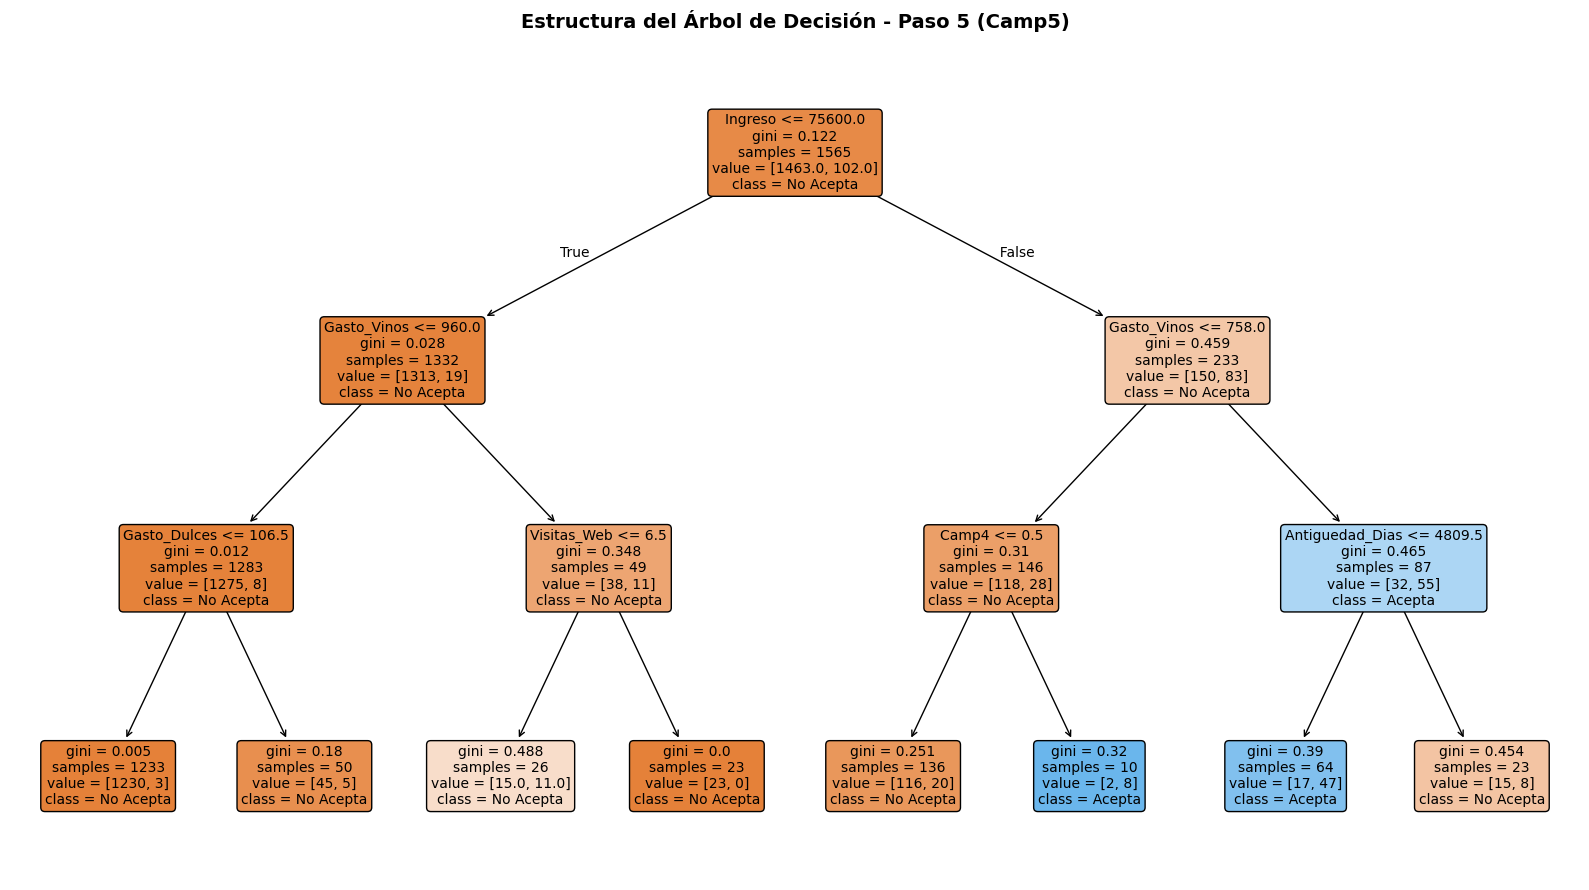


 Prediccion: Ult_Camp
 Usando historial de: Camp1, Camp2, Camp3, Camp4, Camp5
 Exactitud del Árbol de Decisión: 0,8631
 Exactitud del Bosque Aleatorio: 0,8676

   Top 3 variables más importantes (Random Forest):
   - Dias_Ult_Compra: 0,0909
   - Antiguedad_Dias: 0,0792
   - Gasto_Total: 0,0723

   Lista completa de importancia de variables:
   - Dias_Ult_Compra: 0,0909
   - Antiguedad_Dias: 0,0792
   - Gasto_Total: 0,0723
   - Ingreso: 0,0681
   - Gasto_Vinos: 0,0669
   - Gasto_Carne: 0,0606
   - Prod_prem: 0,0500
   - Edad: 0,0430
   - Gasto_Dulces: 0,0407
   - Compras_Fisicas: 0,0394
   - Gasto_Pescado: 0,0377
   - Compras_Catalogo: 0,0373
   - Gasto_Frutas: 0,0371
   - Visitas_Web: 0,0365
   - Camp5: 0,0332
   - Camp3: 0,0290
   - Compras_Web: 0,0288
   - Camp1: 0,0282
   - Compras_Oferta: 0,0233
   - Educacion: 0,0197
   - Camp4: 0,0127
   - Estado_Civil_Casado: 0,0113
   - Hijos_Adolescentes: 0,0108
   - Estado_Civil_Soltero: 0,0106
   - Estado_Civil_En pareja: 0,0083
   - Estado

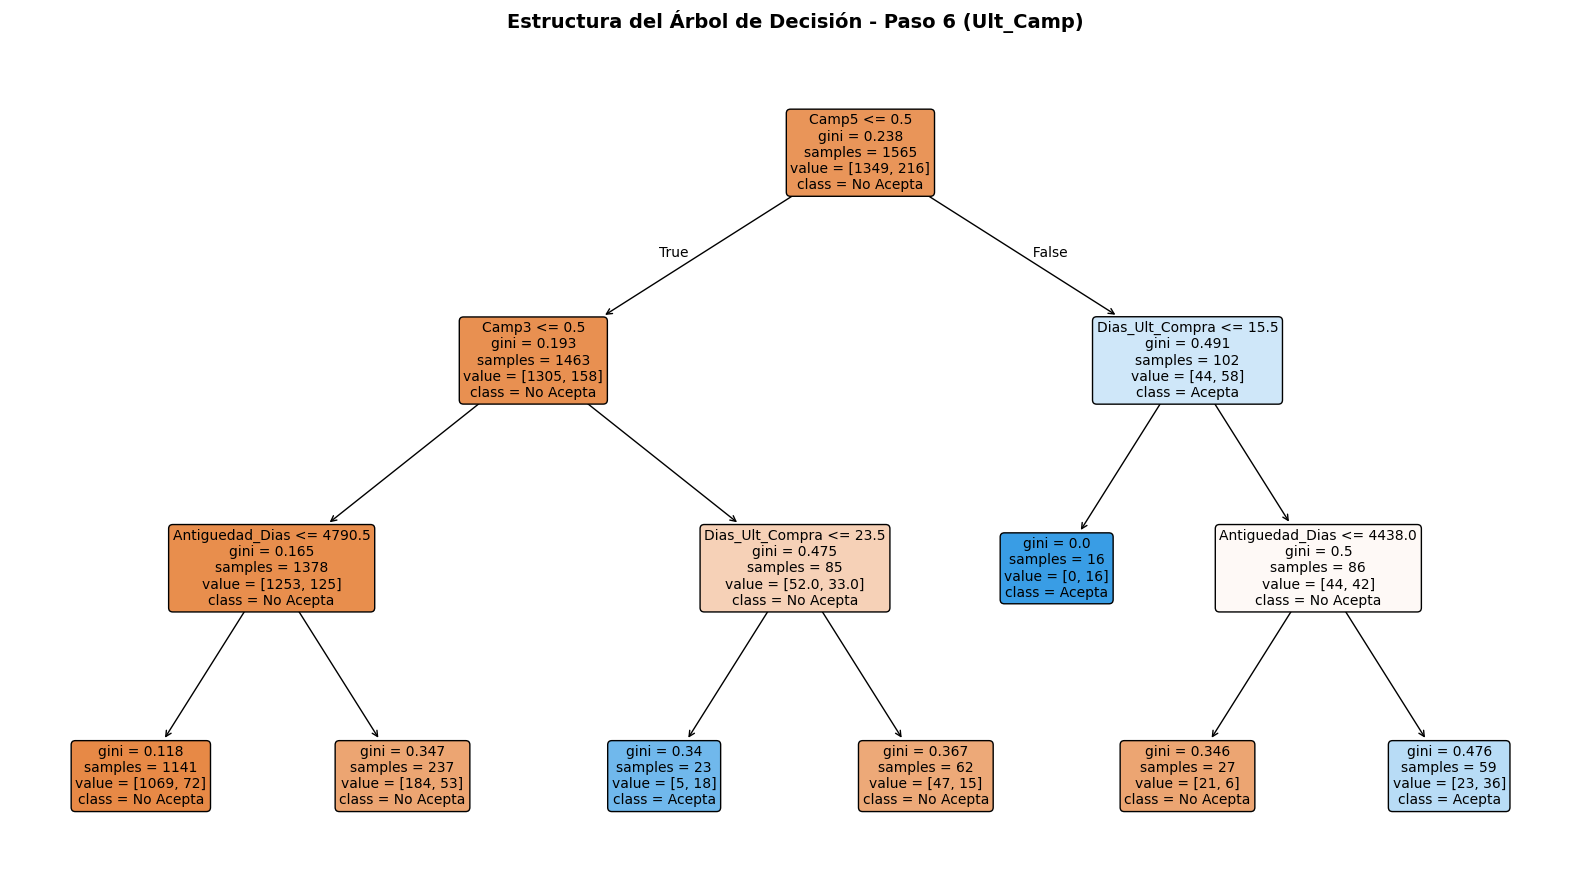

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Definimos TODAS las campañas en orden cronológico
todas_las_campanas = ['Camp1', 'Camp2', 'Camp3', 'Camp4', 'Camp5', 'Ult_Camp']

# -------------------------------------------------------------------
# 2. BUCLE PREDICTIVO CRONOLÓGICO (CON GRÁFICOS ACTIVOS)
# -------------------------------------------------------------------
# Iteramos sobre la lista. En cada vuelta, esa campaña será nuestra "y" (objetivo)
# y usaremos solo las campañas anteriores (si hay) dentro de "X".

for i, camp_objetivo in enumerate(todas_las_campanas):

    # 1. Definimos la variable a predecir en este ciclo
    y = df_final[camp_objetivo]

    # 2. Separamos qué campañas quedan en X y cuáles se excluyen
    campanas_a_excluir = todas_las_campanas[i:]
    campanas_previas_incluidas = todas_las_campanas[:i]

    # Ajustamos el título para que la consola muestre qué estamos usando
    if len(campanas_previas_incluidas) == 0:
        historial_texto = "Ninguna (Solo datos demográficos y base)"
    else:
        historial_texto = f"{', '.join(campanas_previas_incluidas)}"

    print(f"\n{'='*75}")
    print(f" Prediccion: {camp_objetivo}")
    print(f" Usando historial de: {historial_texto}")
    print(f"{'='*75}")

    # Definimos las columnas a excluir para este escenario
    columnas_a_excluir = ['ID', 'Rango_Etario'] + campanas_a_excluir
    X = df_final.drop(columns=columnas_a_excluir)

    # División de datos (70% entrenamiento, 30% prueba)
    XEnt, XTst, yEnt, yTst = train_test_split(X, y, test_size=0.3, random_state=42)

    # --- ÁRBOL DE DECISIÓN ---
    modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
    modelo_arbol.fit(XEnt, yEnt)
    yPred_arbol = modelo_arbol.predict(XTst)
    exactitud_arbol = accuracy_score(yTst, yPred_arbol)

    # --- BOSQUE ALEATORIO (RANDOM FOREST) ---
    modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    modelo_rf.fit(XEnt, yEnt)
    yPred_rf = modelo_rf.predict(XTst)
    exactitud_rf = accuracy_score(yTst, yPred_rf)

    # Formateamos los resultados para mostrar la coma decimal argentina
    acc_arbol_str = f"{exactitud_arbol:.4f}".replace('.', ',')
    acc_rf_str = f"{exactitud_rf:.4f}".replace('.', ',')

    print(f" Exactitud del Árbol de Decisión: {acc_arbol_str}")
    print(f" Exactitud del Bosque Aleatorio: {acc_rf_str}")

    # --- IMPORTANCIA DE LAS VARIABLES ---
    importancias = modelo_rf.feature_importances_
    caracteristicas = X.columns.tolist()
    importancia_vars = sorted(zip(caracteristicas, importancias), key=lambda x: x[1], reverse=True)

    # Apartado 1: Top 3
    print("\n   Top 3 variables más importantes (Random Forest):")
    for nombre, importancia in importancia_vars[:3]:
        imp_str = f"{importancia:.4f}".replace('.', ',')
        print(f"   - {nombre}: {imp_str}")

    # Apartado 2: Lista completa
    print("\n   Lista completa de importancia de variables:")
    for nombre, importancia in importancia_vars:
        imp_str = f"{importancia:.4f}".replace('.', ',')
        print(f"   - {nombre}: {imp_str}")

    # --- 3. VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN ---
    plt.figure(figsize=(16, 9))
    plot_tree(
        modelo_arbol,
        feature_names=X.columns.tolist(),
        class_names=['No Acepta', 'Acepta'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"Estructura del Árbol de Decisión - Paso {i+1} ({camp_objetivo})", fontsize=14, weight='bold', pad=15)
    plt.tight_layout()
    plt.show()